In [ ]:
# ============================================================
# EARLY WARNING OF FOOD INSECURITY USING CADÚNICO MICRODATA
# ============================================================

In [ ]:
# NOTEBOOK 1 — 01_preprocess_and_baselines.ipynb

## Objetivo: deixar o dado pronto e gerar os primeiros modelos base.


# project/
# │
# ├── data/
# │   └── cadunico_2023_2025_union_anon.csv
# │
# ├── outputs/
# │   ├── notebook1/
# │   ├── notebook2/
# │   └── notebook3/
# │
# ├── 01_preprocess_and_baselines.ipynb
# ├── 02_model_comparison_and_final.ipynb
# └── 03_explainability_and_ablation.ipyn

In [ ]:
# Fica responsável por:

# leitura
# inspeção
# limpeza
# split temporal
# feature engineering
# preparação de tipos
# treino/validação de baselines
# salvar artefatos intermediários


# Notebook 1 entrega

# dado limpo
# split temporal
# treino/validação prontos
# baselines avaliados
# artefatos salvos
# preparação dos dados
# validação da pipeline
# salvar artefatos intermediários

# Ou seja, aqui ficam:
# LogisticRegression
# RandomForest

In [1]:
# ============================================================
# CÉLULA 1 — IMPORTS E CONFIGURAÇÃO INICIAL
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import os
import json
import math
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

pd.set_option("display.max_columns", 300)
pd.set_option("display.max_rows", 200)

RANDOM_STATE = 42
TARGET = "inseg_alim_bin"

print("Bibliotecas carregadas com sucesso.")

Bibliotecas carregadas com sucesso.


In [2]:
# ============================================================
# CÉLULA 2 — PARÂMETROS GLOBAIS E CAMINHOS
# ============================================================

FILE_PATH = r"C:\Users\keila\Documents\CSBC2026\CRIA\data\anon_outputs\cadunico_2023_2025_union_anon.csv"

OUTPUT_DIR = "outputs/notebook1"
os.makedirs(OUTPUT_DIR, exist_ok=True)

TRAIN_YEAR = 2024
TEST_YEAR = 2025

MISSING_FLAG_THRESHOLD = 0.05
HIGH_MISSING_DROP_THRESHOLD = 0.95

RARE_CATEGORY_THRESHOLD = 0.005

CLIP_LOWER = 0.01
CLIP_UPPER = 0.99

LEAKAGE_COLS = [
    "d.ind_risco_scl_inseg_alim",
    "pred_prob_risk",
    "pred_class_risk"
]

POSSIBLE_ID_COLS = [
    "id_familia",
    "id_pessoa",
    "id",
    "cpf",
    "nis"
]

print("Arquivo:", FILE_PATH)
print("Existe?", os.path.exists(FILE_PATH))
print("Pasta de saída:", OUTPUT_DIR)

Arquivo: C:\Users\keila\Documents\CSBC2026\CRIA\data\anon_outputs\cadunico_2023_2025_union_anon.csv
Existe? True
Pasta de saída: outputs/notebook1


In [ ]:
# ============================================================
# CÉLULA 3 — LEITURA DOS DADOS
# ============================================================

df = pd.read_csv(FILE_PATH)

print("Dimensão do dataframe:", df.shape)
display(df.head())

# Dimensão do dataframe: (6038705, 171)

Dimensão do dataframe: (6038705, 171)


,ano,d.cd_ibge,d.cod_abaste_agua_domic_fam,d.cod_agua_canalizada_fam,d.cod_banheiro_domic_fam,d.cod_calcamento_domic_fam,d.cod_centro_assist_fam,d.cod_comunidade_quilombola_fam,d.cod_cta_energ_unid_consum_fam,d.cod_destino_lixo_domic_fam,d.cod_eas_fam,d.cod_escoa_sanitario_domic_fam,d.cod_especie_domic_fam,d.cod_est_cadastral_fam,d.cod_familia_indigena_fam,d.cod_forma_coleta_fam,d.cod_iluminacao_domic_fam,d.cod_indigena_reside_fam,d.cod_local_domic_fam,d.cod_material_domic_fam,d.cod_material_piso_fam,d.cod_povo_indigena_fam,d.cod_reserva_indigena_fam,d.dat_atual_fam,d.dat_cadastramento_fam,d.dta_entrevista_fam,d.fx_rfpc,d.ind_familia_quilombola_fam,d.ind_parc_mds_fam,d.ind_risco_scl_inseg_alim,d.ind_risco_scl_vlco_drts,d.marc_pbf,d.nom_centro_assist_fam,d.nom_comunidade_quilombola_fam,d.nom_estab_assist_saude_fam,d.nom_povo_indigena_fam,d.nom_reserva_indigena_fam,d.qtd_comodos_domic_fam,d.qtd_comodos_dormitorio_fam,d.qtd_familias_domic_fam,d.qtd_pessoa_inter_0_17_anos_fam,d.qtd_pessoa_inter_18_64_anos_fam,d.qtd_pessoa_inter_65_anos_fam,d.qtd_pessoas_domic_fam,d.qtde_meses_desat_cat,d.val_desp_agua_esgoto_fam,d.val_desp_alimentacao_fam,d.val_desp_aluguel_fam,d.val_desp_energia_fam,d.val_desp_gas_fam,d.val_desp_medicamentos_fam,d.val_desp_transpor_fam,d.vlr_renda_media_fam,d.vlr_renda_total_fam,fx_renda_individual_805,fx_renda_individual_808,fx_renda_individual_809_1,fx_renda_individual_809_2,fx_renda_individual_809_3,fx_renda_individual_809_4,fx_renda_individual_809_5,inseg_alim_bin,p.cod_afastado_trab_memb,p.cod_agricultura_trab_memb,p.cod_ano_serie_frequenta_memb,p.cod_ano_serie_frequentou_memb,p.cod_cart_assinada_memb,p.cod_censo_inep_memb,p.cod_complemento_pessoa,p.cod_concluiu_frequentou_memb,p.cod_contato_parente_memb,p.cod_curso_frequenta_memb,p.cod_curso_frequentou_pessoa_memb,p.cod_deficiencia_memb,p.cod_escola_local_memb,p.cod_est_cadastral_memb,p.cod_ibge_munic_certid_pessoa,p.cod_ibge_munic_escola_memb,p.cod_ibge_munic_nasc_pessoa,p.cod_local_nascimento_pessoa,p.cod_pais_origem_pessoa,p.cod_parentesco_rf_pessoa,p.cod_principal_trab_memb,p.cod_raca_cor_pessoa,p.cod_sabe_ler_escrever_memb,p.cod_sexo_pessoa,p.cod_tempo_cidade_memb,p.cod_tempo_rua_memb,p.cod_trabalho_12_meses_memb,p.cod_trabalhou_memb,p.cod_vive_fam_rua_memb,p.dta_nasc_pessoa,p.fx_idade,p.fx_renda_individual_805,p.fx_renda_individual_808,p.fx_renda_individual_809_1,p.fx_renda_individual_809_2,p.fx_renda_individual_809_3,p.fx_renda_individual_809_4,p.fx_renda_individual_809_5,p.grau_instrucao,p.ind_ajuda_especializado_memb,p.ind_ajuda_familia_memb,p.ind_ajuda_instituicao_memb,p.ind_ajuda_nao_memb,p.ind_ajuda_outra_memb,p.ind_ajuda_vizinho_memb,p.ind_atend_centro_ref_rua_memb,p.ind_atend_cras_memb,p.ind_atend_creas_memb,p.ind_atend_hospital_geral_memb,p.ind_atend_inst_gov_memb,p.ind_atend_inst_nao_gov_memb,p.ind_atend_nenhum_memb,p.ind_ativ_com_coop_memb,p.ind_ativ_com_escola_memb,p.ind_ativ_com_mov_soc_memb,p.ind_ativ_com_nao_resp_memb,p.ind_ativ_com_nao_sabe_memb,p.ind_def_baixa_visao_memb,p.ind_def_cegueira_memb,p.ind_def_fisica_memb,p.ind_def_mental_memb,p.ind_def_sindrome_down_memb,p.ind_def_surdez_leve_memb,p.ind_def_surdez_profunda_memb,p.ind_def_transtorno_mental_memb,p.ind_dinh_carregador_memb,p.ind_dinh_catador_memb,p.ind_dinh_const_memb,p.ind_dinh_flanelhinha_memb,p.ind_dinh_nao_resp_memb,p.ind_dinh_outro_memb,p.ind_dinh_pede_memb,p.ind_dinh_servs_gerais_memb,p.ind_dinh_vendas_memb,p.ind_dormir_albergue_memb,p.ind_dormir_dom_part_memb,p.ind_dormir_rua_memb,p.ind_frequenta_escola_memb,p.ind_identidade_genero,p.ind_motivo_alcool_memb,p.ind_motivo_ameaca_memb,p.ind_motivo_desemprego_memb,p.ind_motivo_nao_resp_memb,p.ind_motivo_nao_sabe_memb,p.ind_motivo_outro_memb,p.ind_motivo_perda_memb,p.ind_motivo_pref_memb,p.ind_motivo_probs_fam_memb,p.ind_motivo_saude_memb,p.ind_motivo_trabalho_memb,p.ind_outro_memb,p.ind_tipo_identidade_genero,p.ind_trabalho_infantil_pessoa,p.ind_transgenero,p.marc_pab,p.marc_pbf,p.marc_sit_rua,p.nom_escola_memb,p.nom_ibge_m

In [21]:
# ============================================================
# CÉLULA 4 — INSPEÇÃO INICIAL
# ============================================================

print("Total de colunas:", len(df.columns))

print("\nTipos de dados:")
display(df.dtypes.value_counts())

print("\nTop 30 colunas com maior percentual de missing:")
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
display(missing_pct.head(30))

if TARGET in df.columns:
    print(f"\nDistribuição bruta do alvo '{TARGET}':")
    display(df[TARGET].value_counts(dropna=False))
else:
    print(f"Atenção: alvo '{TARGET}' não encontrado.")

if "ano" in df.columns:
    print("\nDistribuição por ano:")
    display(df["ano"].value_counts(dropna=False).sort_index())


# Total de colunas: 171

# Tipos de dados:
# float64    139
# object      18
# int64       14

# Top 30 colunas com maior percentual de missing:

# p.qtd_dormir_freq_dom_part_memb    99.991935
# p.qtd_freq_outro_memb              99.981784
# p.nom_pais_origem_pessoa           99.965655
# p.qtd_dormir_freq_albergue_memb    99.962310
# p.qtd_dormir_freq_rua_memb         99.918228
# p.ind_def_sindrome_down_memb       99.916770
# p.ind_ajuda_vizinho_memb           99.915810
# d.ind_risco_scl_vlco_drts          99.915445
# p.ind_ajuda_outra_memb             99.881001
# p.ind_dormir_dom_part_memb         99.868664
# p.ind_dormir_albergue_memb         99.868101
# p.ind_outro_memb                   99.868084
# p.ind_dormir_rua_memb              99.866047
# p.cod_tempo_rua_memb               99.865087
# p.ind_atend_inst_nao_gov_memb      99.865087
# p.ind_ativ_com_mov_soc_memb        99.865087
# p.ind_ativ_com_escola_memb         99.865087
# p.ind_ativ_com_coop_memb           99.865087
# p.ind_atend_nenhum_memb            99.865087
# p.ind_motivo_outro_memb            99.865087
# p.ind_motivo_nao_sabe_memb         99.865087
# p.ind_atend_hospital_geral_memb    99.865087
# p.ind_atend_inst_gov_memb          99.865087
# p.cod_vive_fam_rua_memb            99.865087
# p.ind_atend_creas_memb             99.865087
# p.ind_atend_cras_memb              99.865087
# p.ind_atend_centro_ref_rua_memb    99.865087
# p.cod_cart_assinada_memb           99.865087
# p.cod_tempo_cidade_memb            99.865087
# p.ind_motivo_desemprego_memb       99.865087

# Distribuição bruta do alvo 'inseg_alim_bin':
# inseg_alim_bin
# NaN    5158346
# 0.0     807489
# 1.0      72870

# Distribuição por ano:
# ano
# 2023    2013017
# 2024    2007172
# 2025    2018516

Total de colunas: 171

Tipos de dados:


float64    138
object      18
int64       14
int32        1
Name: count, dtype: int64


Top 30 colunas com maior percentual de missing:


p.qtd_dormir_freq_dom_part_memb    99.994775
p.qtd_freq_outro_memb              99.984552
p.nom_pais_origem_pessoa           99.979327
p.qtd_dormir_freq_albergue_memb    99.973647
p.qtd_dormir_freq_rua_memb         99.956722
p.ind_ajuda_vizinho_memb           99.947067
p.ind_def_sindrome_down_memb       99.919237
p.ind_dinh_carregador_memb         99.916171
p.ind_dinh_catador_memb            99.916171
p.ind_motivo_trabalho_memb         99.916171
p.cod_cart_assinada_memb           99.916171
p.ind_dinh_const_memb              99.916171
p.ind_dinh_flanelhinha_memb        99.916171
p.ind_dinh_nao_resp_memb           99.916171
p.ind_dinh_outro_memb              99.916171
p.ind_dinh_pede_memb               99.916171
p.ind_dinh_servs_gerais_memb       99.916171
p.ind_atend_inst_gov_memb          99.916171
p.ind_outro_memb                   99.916171
p.cod_contato_parente_memb         99.916171
p.ind_dormir_albergue_memb         99.916171
p.ind_ativ_com_nao_sabe_memb       99.916171
p.ind_ativ


Distribuição bruta do alvo 'inseg_alim_bin':


inseg_alim_bin
0    807489
1     72870
Name: count, dtype: int64


Distribuição por ano:


ano
2024    449323
2025    431036
Name: count, dtype: int64

In [22]:
# 1. Calcular explicitamente a taxa de positivos entre os casos válidos
if TARGET in df.columns:
    valid_target = df[TARGET].dropna()
    pos_rate = (valid_target == 1).mean() * 100
    print(f"\nTarget valid records: {len(valid_target):,}")
    print(f"Positive rate among valid target records: {pos_rate:.2f}%")

# 2. Mostrar quantas colunas têm missing acima de certos cortes
print("\nColumns with missing > 95%:", (missing_pct > 95).sum())
print("Columns with missing > 99%:", (missing_pct > 99).sum())

# Target valid records: 880,359
# Positive rate among valid target records: 8.28%

# Columns with missing > 95%: 71
# Columns with missing > 99%: 61


Target valid records: 880,359
Positive rate among valid target records: 8.28%

Columns with missing > 95%: 71
Columns with missing > 99%: 62


In [23]:
# 3. Mostrar a distribuição do alvo por ano entre registros válidos

if TARGET in df.columns and "ano" in df.columns:
    print("\nTarget distribution by year (valid target only):")
    display(
        df[df[TARGET].notna()]
        .groupby("ano")[TARGET]
        .value_counts(normalize=False)
        .rename("count")
    )

    print("\nTarget proportion by year (valid target only):")
    display(
        df[df[TARGET].notna()]
        .groupby("ano")[TARGET]
        .value_counts(normalize=True)
        .rename("proportion")
    )

# Target distribution by year (valid target only):
# ano   inseg_alim_bin
# 2024  0                 412492
#       1                  36831
# 2025  0                 394997
#       1                  36039

# Target proportion by year (valid target only):
# ano   inseg_alim_bin
# 2024  0                 0.91803
#       1                 0.08197
# 2025  0                 0.91639
#       1                 0.08361



Target distribution by year (valid target only):


ano   inseg_alim_bin
2024  0                 412492
      1                  36831
2025  0                 394997
      1                  36039
Name: count, dtype: int64


Target proportion by year (valid target only):


ano   inseg_alim_bin
2024  0                 0.91803
      1                 0.08197
2025  0                 0.91639
      1                 0.08361
Name: proportion, dtype: float64

A base de dados harmonizada utilizada neste estudo é composta por 171 variáveis, predominantemente numéricas, o que favorece a aplicação de modelos supervisionados voltados a dados tabulares. Essa predominância de atributos numéricos reduz a necessidade de transformações complexas e permite a utilização eficiente de algoritmos baseados em árvores e métodos de gradiente boosting.

Entretanto, a análise exploratória inicial revelou a presença de um número expressivo de variáveis com elevada proporção de valores ausentes. Especificamente, 71 variáveis apresentam mais de 95% de dados faltantes, das quais 61 ultrapassam o limiar de 99%. Esse padrão indica que tais atributos possuem baixa representatividade global na base e, portanto, contribuem pouco para a capacidade preditiva dos modelos. Diante disso, a remoção dessas variáveis foi considerada uma etapa necessária de pré-processamento, com o objetivo de reduzir ruído, evitar sparsity excessiva e melhorar a generalização dos modelos.

No que se refere à variável alvo, observa-se que, dos mais de seis milhões de registros totais, apenas 880.359 possuem valores válidos para o indicador de insegurança alimentar. Entre esses registros, a classe positiva representa aproximadamente 8,28%, caracterizando um cenário de forte desbalanceamento. Esse desequilíbrio implica desafios relevantes para a modelagem, uma vez que modelos tradicionais tendem a favorecer a classe majoritária. Por esse motivo, métricas como AUC-PR e recall tornam-se mais adequadas para a avaliação do desempenho preditivo, em detrimento da acurácia.

A análise temporal da distribuição do alvo indica estabilidade entre os anos de 2024 e 2025. Em 2024, a proporção de casos positivos é de aproximadamente 8,20%, enquanto em 2025 esse valor é de cerca de 8,36%. Essa variação é pequena, sugerindo que a prevalência do fenômeno se mantém consistente ao longo do tempo. Em termos absolutos, foram observados 36.831 casos positivos em 2024 e 36.039 em 2025, com números semelhantes também para a classe negativa. Essa estabilidade temporal é um fator importante, pois indica que os padrões aprendidos pelos modelos em dados de um ano têm potencial para generalizar para períodos subsequentes.

Em conjunto, esses resultados evidenciam que a base apresenta características típicas de dados administrativos em larga escala: alta dimensionalidade, presença significativa de valores ausentes e forte desbalanceamento da variável alvo. Ao mesmo tempo, a consistência temporal e a estrutura dos dados indicam que o problema é passível de modelagem preditiva robusta, desde que sejam adotadas estratégias adequadas de pré-processamento, seleção de atributos e avaliação de desempenho.

In [24]:
# ============================================================
# CÉLULA 5 — LIMPEZA DO ALVO
# ============================================================

df = df.copy()

df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce")
df = df[np.isfinite(df[TARGET])]
df = df[df[TARGET].isin([0, 1])].copy()
df[TARGET] = df[TARGET].astype(int)

print("Dimensão após limpeza do alvo:", df.shape)

print("\nDistribuição final do alvo:")
display(df[TARGET].value_counts(normalize=True).rename("proporcao"))

# Dimensão após limpeza do alvo: (880359, 171)

# Distribuição final do alvo:
# inseg_alim_bin
# 0    0.917227
# 1    0.082773

Dimensão após limpeza do alvo: (880359, 171)

Distribuição final do alvo:


inseg_alim_bin
0    0.917227
1    0.082773
Name: proporcao, dtype: float64

In [25]:
# 1. Mostrar números absolutos também
print("\nDistribuição absoluta:")
display(df[TARGET].value_counts())

# 2. Mostrar razão negativa/positiva
neg, pos = df[TARGET].value_counts()
print(f"\nRazão Negativo/Positivo: {neg/pos:.2f}:1")

# 3. Print mais explicativo
print(f"\nTotal de registros com alvo válido: {len(df):,}")
print(f"Classe positiva: {pos} ({pos/len(df)*100:.2f}%)")
print(f"Classe negativa: {neg} ({neg/len(df)*100:.2f}%)")

# Distribuição absoluta:
# inseg_alim_bin
# 0    807489
# 1     72870

# Razão Negativo/Positivo: 11.08:1

# Total de registros com alvo válido: 880,359
# Classe positiva: 72870 (8.28%)
# Classe negativa: 807489 (91.72%)


Distribuição absoluta:


inseg_alim_bin
0    807489
1     72870
Name: count, dtype: int64


Razão Negativo/Positivo: 11.08:1

Total de registros com alvo válido: 880,359
Classe positiva: 72870 (8.28%)
Classe negativa: 807489 (91.72%)


A etapa de limpeza da variável alvo resultou em um conjunto de 880.359 registros com valores válidos para o indicador de insegurança alimentar. A distribuição das classes revela um cenário de forte desbalanceamento, no qual 807.489 observações (91,72%) pertencem à classe negativa, enquanto apenas 72.870 registros (8,28%) correspondem à classe positiva. Essa configuração implica uma razão aproximada de 11:1 entre as classes negativa e positiva.

Esse padrão é característico de problemas reais envolvendo vulnerabilidade social, nos quais eventos de interesse são relativamente raros. No entanto, tal desbalanceamento impõe desafios significativos para a modelagem preditiva, uma vez que modelos tradicionais tendem a favorecer a classe majoritária, podendo alcançar elevados níveis de acurácia mesmo sem identificar adequadamente os casos positivos.

Diante desse cenário, a acurácia não é uma métrica adequada para avaliar o desempenho dos modelos. Em vez disso, priorizam-se métricas mais sensíveis à classe minoritária, como a área sob a curva Precision-Recall (AUC-PR) e o recall. Em particular, o recall é fundamental neste contexto, pois mede a capacidade do modelo de identificar corretamente famílias em situação de risco, reduzindo a ocorrência de falsos negativos, que representam falhas críticas em aplicações voltadas à formulação de políticas públicas.

In [26]:
# ============================================================
# CÉLULA 6 — SPLIT TEMPORAL
# ============================================================

df_trainval = df[df["ano"] == TRAIN_YEAR].copy()
df_test = df[df["ano"] == TEST_YEAR].copy()

print("Treino/validação (2024):", df_trainval.shape)
print("Teste temporal (2025):", df_test.shape)

print("\nPrevalência do alvo em 2024:")
display(df_trainval[TARGET].value_counts(normalize=True).rename("proporcao"))

print("\nPrevalência do alvo em 2025:")
display(df_test[TARGET].value_counts(normalize=True).rename("proporcao"))

# Treino/validação (2024): (449323, 171)
# Teste temporal (2025): (431036, 171)

# Prevalência do alvo em 2024:
# inseg_alim_bin
# 0    0.91803
# 1    0.08197

# Prevalência do alvo em 2025:
# inseg_alim_bin
# 0    0.91639
# 1    0.08361


Treino/validação (2024): (449323, 171)
Teste temporal (2025): (431036, 171)

Prevalência do alvo em 2024:


inseg_alim_bin
0    0.91803
1    0.08197
Name: proporcao, dtype: float64


Prevalência do alvo em 2025:


inseg_alim_bin
0    0.91639
1    0.08361
Name: proporcao, dtype: float64

A divisão dos dados foi realizada de forma temporal, utilizando os registros de 2024 para treinamento e validação (449.323 observações) e os dados de 2025 como conjunto de teste (431.036 observações), simulando um cenário realista de aplicação no qual o modelo é treinado com informações passadas para prever eventos futuros. A análise da distribuição da variável alvo ao longo dos anos revela elevada estabilidade na prevalência do fenômeno, com aproximadamente 8,20% de casos positivos em 2024 e 8,36% em 2025. Essa consistência temporal indica ausência de mudanças abruptas na distribuição do risco de insegurança alimentar, favorecendo a capacidade de generalização dos modelos e reforçando a robustez metodológica do estudo, uma vez que reduz o risco de viés associado a divisões aleatórias e aproxima o experimento de condições reais de uso.

In [ ]:
import pandas as pd

pd.Series(df.columns).sort_values().reset_index(drop=True)

#  ano
# 1                               d.cd_ibge
# 2             d.cod_abaste_agua_domic_fam
# 3               d.cod_agua_canalizada_fam
# 4                d.cod_banheiro_domic_fam
# 5              d.cod_calcamento_domic_fam
# 6                 d.cod_centro_assist_fam
# 7         d.cod_comunidade_quilombola_fam
# 8         d.cod_cta_energ_unid_consum_fam
# 9            d.cod_destino_lixo_domic_fam
# 10                          d.cod_eas_fam
# 11        d.cod_escoa_sanitario_domic_fam
# 12                d.cod_especie_domic_fam
# 13                d.cod_est_cadastral_fam
# 14             d.cod_familia_indigena_fam
# 15                 d.cod_forma_coleta_fam
# 16             d.cod_iluminacao_domic_fam
# 17              d.cod_indigena_reside_fam
# 18                  d.cod_local_domic_fam
# 19               d.cod_material_domic_fam
# 20                d.cod_material_piso_fam
# 21                d.cod_povo_indigena_fam
# 22             d.cod_reserva_indigena_fam
# 23                        d.dat_atual_fam
# 24                d.dat_cadastramento_fam
# 25                   d.dta_entrevista_fam
# 26                              d.fx_rfpc
# 27           d.ind_familia_quilombola_fam
# 28                     d.ind_parc_mds_fam
# 29             d.ind_risco_scl_inseg_alim
# 30              d.ind_risco_scl_vlco_drts
# 31                             d.marc_pbf
# 32                d.nom_centro_assist_fam
# 33        d.nom_comunidade_quilombola_fam
# 34           d.nom_estab_assist_saude_fam
# 35                d.nom_povo_indigena_fam
# 36             d.nom_reserva_indigena_fam
# 37                d.qtd_comodos_domic_fam
# 38           d.qtd_comodos_dormitorio_fam
# 39               d.qtd_familias_domic_fam
# 40       d.qtd_pessoa_inter_0_17_anos_fam
# 41      d.qtd_pessoa_inter_18_64_anos_fam
# 42         d.qtd_pessoa_inter_65_anos_fam
# 43                d.qtd_pessoas_domic_fam
# 44                 d.qtde_meses_desat_cat
# 45             d.val_desp_agua_esgoto_fam
# 46             d.val_desp_alimentacao_fam
# 47                 d.val_desp_aluguel_fam
# 48                 d.val_desp_energia_fam
# 49                     d.val_desp_gas_fam
# 50            d.val_desp_medicamentos_fam
# 51                d.val_desp_transpor_fam
# 52                  d.vlr_renda_media_fam
# 53                  d.vlr_renda_total_fam
# 54                fx_renda_individual_805
# 55                fx_renda_individual_808
# 56              fx_renda_individual_809_1
# 57              fx_renda_individual_809_2
# 58              fx_renda_individual_809_3
# 59              fx_renda_individual_809_4
# 60              fx_renda_individual_809_5
# 61                         inseg_alim_bin
# 62               p.cod_afastado_trab_memb
# 63            p.cod_agricultura_trab_memb
# 64         p.cod_ano_serie_frequenta_memb
# 65        p.cod_ano_serie_frequentou_memb
# 66               p.cod_cart_assinada_memb
# 67                  p.cod_censo_inep_memb
# 68               p.cod_complemento_pessoa
# 69         p.cod_concluiu_frequentou_memb
# 70             p.cod_contato_parente_memb
# 71             p.cod_curso_frequenta_memb
# 72     p.cod_curso_frequentou_pessoa_memb
# 73                 p.cod_deficiencia_memb
# 74                p.cod_escola_local_memb
# 75               p.cod_est_cadastral_memb
# 76         p.cod_ibge_munic_certid_pessoa
# 77           p.cod_ibge_munic_escola_memb
# 78           p.cod_ibge_munic_nasc_pessoa
# 79          p.cod_local_nascimento_pessoa
# 80               p.cod_pais_origem_pessoa
# 81             p.cod_parentesco_rf_pessoa
# 82              p.cod_principal_trab_memb
# 83                  p.cod_raca_cor_pessoa
# 84           p.cod_sabe_ler_escrever_memb
# 85                      p.cod_sexo_pessoa
# 86                p.cod_tempo_cidade_memb
# 87                   p.cod_tempo_rua_memb
# 88           p.cod_trabalho_12_meses_memb
# 89                   p.cod_trabalhou_memb
# 90                p.cod_vive_fam_rua_memb
# 91                      p.dta_nasc_pessoa
# 92                             p.fx_idade
# 93              p.fx_renda_individual_805
# 94              p.fx_renda_individual_808
# 95            p.fx_renda_individual_809_1
# 96            p.fx_renda_individual_809_2
# 97            p.fx_renda_individual_809_3
# 98            p.fx_renda_individual_809_4
# 99            p.fx_renda_individual_809_5
# 100                      p.grau_instrucao
# 101        p.ind_ajuda_especializado_memb
# 102              p.ind_ajuda_familia_memb
# 103          p.ind_ajuda_instituicao_memb
# 104                  p.ind_ajuda_nao_memb
# 105                p.ind_ajuda_outra_memb
# 106              p.ind_ajuda_vizinho_memb
# 107       p.ind_atend_centro_ref_rua_memb
# 108                 p.ind_atend_cras_memb
# 109                p.ind_atend_creas_memb
# 110       p.ind_atend_hospital_geral_memb
# 111             p.ind_atend_inst_gov_memb
# 112         p.ind_atend_inst_nao_gov_memb
# 113               p.ind_atend_nenhum_memb
# 114              p.ind_ativ_com_coop_memb
# 115            p.ind_ativ_com_escola_memb
# 116           p.ind_ativ_com_mov_soc_memb
# 117          p.ind_ativ_com_nao_resp_memb
# 118          p.ind_ativ_com_nao_sabe_memb
# 119            p.ind_def_baixa_visao_memb
# 120               p.ind_def_cegueira_memb
# 121                 p.ind_def_fisica_memb
# 122                 p.ind_def_mental_memb
# 123          p.ind_def_sindrome_down_memb
# 124            p.ind_def_surdez_leve_memb
# 125        p.ind_def_surdez_profunda_memb
# 126      p.ind_def_transtorno_mental_memb
# 127            p.ind_dinh_carregador_memb
# 128               p.ind_dinh_catador_memb
# 129                 p.ind_dinh_const_memb
# 130           p.ind_dinh_flanelhinha_memb
# 131              p.ind_dinh_nao_resp_memb
# 132                 p.ind_dinh_outro_memb
# 133                  p.ind_dinh_pede_memb
# 134          p.ind_dinh_servs_gerais_memb
# 135                p.ind_dinh_vendas_memb
# 136            p.ind_dormir_albergue_memb
# 137            p.ind_dormir_dom_part_memb
# 138                 p.ind_dormir_rua_memb
# 139           p.ind_frequenta_escola_memb
# 140               p.ind_identidade_genero
# 141              p.ind_motivo_alcool_memb
# 142              p.ind_motivo_ameaca_memb
# 143          p.ind_motivo_desemprego_memb
# 144            p.ind_motivo_nao_resp_memb
# 145            p.ind_motivo_nao_sabe_memb
# 146               p.ind_motivo_outro_memb
# 147               p.ind_motivo_perda_memb
# 148                p.ind_motivo_pref_memb
# 149           p.ind_motivo_probs_fam_memb
# 150               p.ind_motivo_saude_memb
# 151            p.ind_motivo_trabalho_memb
# 152                      p.ind_outro_memb
# 153          p.ind_tipo_identidade_genero
# 154        p.ind_trabalho_infantil_pessoa
# 155                     p.ind_transgenero
# 156                            p.marc_pab
# 157                            p.marc_pbf
# 158                        p.marc_sit_rua
# 159                     p.nom_escola_memb
# 160          p.nom_ibge_munic_nasc_pessoa
# 161             p.nom_munic_certid_pessoa
# 162               p.nom_munic_escola_memb
# 163              p.nom_pais_origem_pessoa
# 164       p.qtd_dormir_freq_albergue_memb
# 165       p.qtd_dormir_freq_dom_part_memb
# 166            p.qtd_dormir_freq_rua_memb
# 167                 p.qtd_freq_outro_memb
# 168             p.qtd_meses_12_meses_memb
# 169                  p.sig_uf_escola_memb
# 170            p.sig_uf_munic_nasc_pessoa


0                                     ano
1                               d.cd_ibge
2             d.cod_abaste_agua_domic_fam
3               d.cod_agua_canalizada_fam
4                d.cod_banheiro_domic_fam
5              d.cod_calcamento_domic_fam
6                 d.cod_centro_assist_fam
7         d.cod_comunidade_quilombola_fam
8         d.cod_cta_energ_unid_consum_fam
9            d.cod_destino_lixo_domic_fam
10                          d.cod_eas_fam
11        d.cod_escoa_sanitario_domic_fam
12                d.cod_especie_domic_fam
13                d.cod_est_cadastral_fam
14             d.cod_familia_indigena_fam
15                 d.cod_forma_coleta_fam
16             d.cod_iluminacao_domic_fam
17              d.cod_indigena_reside_fam
18                  d.cod_local_domic_fam
19               d.cod_material_domic_fam
20                d.cod_material_piso_fam
21                d.cod_povo_indigena_fam
22             d.cod_reserva_indigena_fam
23                        d.dat_at

In [27]:
# ============================================================
# CÉLULA 7 — FUNÇÕES AUXILIARES
# ============================================================

def add_date_parts(df_in):
    """
    Cria atributos derivados de colunas de data com base em nomes sugestivos.
    """
    df_out = df_in.copy()

    date_keywords = ["data", "dt_", "_dt", "date", "atualizacao", "cadastro", "entrevista"]
    candidate_cols = [c for c in df_out.columns if any(k in c.lower() for k in date_keywords)]

    for col in candidate_cols:
        try:
            dt = pd.to_datetime(df_out[col], errors="coerce")
            if dt.notna().sum() == 0:
                continue

            df_out[f"{col}_ano"] = dt.dt.year
            df_out[f"{col}_mes"] = dt.dt.month
            df_out[f"{col}_dia"] = dt.dt.day
            df_out[f"{col}_dia_semana"] = dt.dt.dayofweek
            df_out[f"{col}_eh_fim_mes"] = dt.dt.is_month_end.astype("float")
            df_out[f"{col}_eh_inicio_mes"] = dt.dt.is_month_start.astype("float")
        except Exception:
            pass

    return df_out


def add_missing_flags(df_in, threshold=0.10):
    """
    Cria flags binárias de ausência para colunas com missing >= threshold.
    """
    df_out = df_in.copy()
    missing_rate = df_out.isna().mean()
    cols_flag = missing_rate[missing_rate >= threshold].index.tolist()

    for col in cols_flag:
        df_out[f"{col}_is_missing"] = df_out[col].isna().astype(int)

    return df_out


def apply_feature_engineering(df_in):
    """
    Aplica feature engineering principal.
    """
    eps = 1e-6
    df_out = df_in.copy()
    # ============================================================
    # Datas
    # ============================================================
    df_out = add_date_parts(df_out)
    # ============================================================
    # Missing flags
    # ============================================================
    df_out = add_missing_flags(df_out, threshold=MISSING_FLAG_THRESHOLD)
    # ============================================================
    # Densidade domiciliar
    # ============================================================
    if {"d.qtd_pessoas_domic_fam", "d.qtd_comodos_dormitorio_fam"}.issubset(df_out.columns):
        df_out["feat_densidade_domiciliar"] = (
            df_out["d.qtd_pessoas_domic_fam"] /
            (df_out["d.qtd_comodos_dormitorio_fam"].replace(0, np.nan) + eps)
        )
    # ============================================================
    # Proporção de dependentes
    # ============================================================
    if {
        "d.qtd_pessoa_inter_0_17_anos_fam",
        "d.qtd_pessoa_inter_65_anos_fam",
        "d.qtd_pessoas_domic_fam"
    }.issubset(df_out.columns):
        df_out["feat_proporcao_dependentes"] = (
            df_out["d.qtd_pessoa_inter_0_17_anos_fam"].fillna(0) +
            df_out["d.qtd_pessoa_inter_65_anos_fam"].fillna(0)
        ) / (df_out["d.qtd_pessoas_domic_fam"].replace(0, np.nan) + eps)
    # ============================================================
    # Banheiro por morador
    # ============================================================
    if {"d.qtd_banheiros_fam", "d.qtd_pessoas_domic_fam"}.issubset(df_out.columns):
        df_out["feat_banheiro_por_morador"] = (
            df_out["d.qtd_banheiros_fam"] /
            (df_out["d.qtd_pessoas_domic_fam"].replace(0, np.nan) + eps)
        )
    # ============================================================
    # Renda per capita (MUITO IMPORTANTE)
    # ============================================================
    if {"d.vlr_renda_total_fam", "d.qtd_pessoas_domic_fam"}.issubset(df_out.columns):
        df_out["feat_renda_per_capita"] = (
            df_out["d.vlr_renda_total_fam"] /
            (df_out["d.qtd_pessoas_domic_fam"].replace(0, np.nan) + eps)
        )
    # ============================================================
    # Pressão alimentar (CRÍTICA)
    # ============================================================
    if {"d.val_desp_alimentacao_fam", "d.vlr_renda_total_fam"}.issubset(df_out.columns):
        df_out["feat_pressao_alimentar"] = (
            df_out["d.val_desp_alimentacao_fam"] /
            (df_out["d.vlr_renda_total_fam"].replace(0, np.nan) + eps)
        )
    # ============================================================
    # Log renda
    # ============================================================
    renda_cols = [
        "d.vlr_renda_total_fam",
        "d.vlr_renda_media_fam"
    ]

    for col in renda_cols:
        if col in df_out.columns:
            df_out[f"{col}_log1p"] = np.log1p(
                pd.to_numeric(df_out[col], errors="coerce").clip(lower=0)
            )

    return df_out

def prepare_types_for_models(train_df, test_df, low_cardinality_threshold=20, drop_high_missing=True):
    """
    Prepara tipos para modelos tabulares.
    - mantém apenas colunas comuns
    - remove colunas com missing extremo
    - trata datas explícitas
    - converte objetos para número ou category
    - converte códigos de baixa cardinalidade em category
    """
    train_df = train_df.copy()
    test_df = test_df.copy()

    common_cols = [c for c in train_df.columns if c in test_df.columns]
    train_df = train_df[common_cols].copy()
    test_df = test_df[common_cols].copy()

    explicit_date_cols = [
        "d.dat_atual_fam",
        "d.dat_cadastramento_fam",
        "d.dta_entrevista_fam",
        "p.dta_nasc_pessoa"
    ]
    explicit_date_cols = [c for c in explicit_date_cols if c in train_df.columns and c in test_df.columns]

    for col in explicit_date_cols:
        train_dt = pd.to_datetime(train_df[col], errors="coerce")
        test_dt = pd.to_datetime(test_df[col], errors="coerce")

        train_df[f"{col}_ano"] = train_dt.dt.year
        test_df[f"{col}_ano"] = test_dt.dt.year

        train_df[f"{col}_mes"] = train_dt.dt.month
        test_df[f"{col}_mes"] = test_dt.dt.month

        train_df[f"{col}_dia"] = train_dt.dt.day
        test_df[f"{col}_dia"] = test_dt.dt.day

        train_df[f"{col}_dia_semana"] = train_dt.dt.dayofweek
        test_df[f"{col}_dia_semana"] = test_dt.dt.dayofweek

        if col == "p.dta_nasc_pessoa":
            ref_train = pd.Timestamp(f"{TRAIN_YEAR}-12-31")
            ref_test = pd.Timestamp(f"{TEST_YEAR}-12-31")
            train_df["p.idade_aprox"] = (ref_train - train_dt).dt.days / 365.25
            test_df["p.idade_aprox"] = (ref_test - test_dt).dt.days / 365.25

    train_df = train_df.drop(columns=explicit_date_cols, errors="ignore")
    test_df = test_df.drop(columns=explicit_date_cols, errors="ignore")

    common_cols = [c for c in train_df.columns if c in test_df.columns]

    for col in common_cols:
        if str(train_df[col].dtype) == "object":
            train_num = pd.to_numeric(train_df[col], errors="coerce")
            test_num = pd.to_numeric(test_df[col], errors="coerce")

            n_orig = train_df[col].notna().sum()
            n_conv = train_num.notna().sum()
            conversion_rate = n_conv / n_orig if n_orig > 0 else 0

            if conversion_rate >= 0.95:
                train_df[col] = train_num
                test_df[col] = test_num
            else:
                train_df[col] = train_df[col].fillna("MISSING").astype(str).astype("category")
                test_df[col] = test_df[col].fillna("MISSING").astype(str).astype("category")

    common_cols = [c for c in train_df.columns if c in test_df.columns]

    for col in common_cols:
        if pd.api.types.is_numeric_dtype(train_df[col]):
            nunique = train_df[col].nunique(dropna=True)
            col_lower = col.lower()

            looks_categorical = (
                nunique <= low_cardinality_threshold or
                col_lower.startswith("cod_") or ".cod_" in col_lower or
                col_lower.startswith("ind_") or ".ind_" in col_lower or
                col_lower.startswith("fx_") or ".fx_" in col_lower or
                col_lower.startswith("sig_") or ".sig_" in col_lower
            )

            looks_count = (
                "qtd_" in col_lower or ".qtd_" in col_lower or
                "vlr_" in col_lower or ".vlr_" in col_lower or
                "idade" in col_lower
            )

            if looks_categorical and not looks_count:
                try:
                    train_df[col] = train_df[col].astype("Int64").astype("category")
                    test_df[col] = test_df[col].astype("Int64").astype("category")
                except Exception:
                    pass

    if drop_high_missing:
        missing_rate = train_df.isna().mean()
        cols_to_drop = missing_rate[missing_rate >= HIGH_MISSING_DROP_THRESHOLD].index.tolist()

        if cols_to_drop:
            print("Removendo colunas com missing >= 95%:", len(cols_to_drop))
            train_df = train_df.drop(columns=cols_to_drop, errors="ignore")
            test_df = test_df.drop(columns=cols_to_drop, errors="ignore")

    return train_df, test_df


def group_rare_categories(train_df, other_dfs, min_freq=0.005, rare_label="__RARE__"):
    """
    Agrupa categorias raras usando apenas o treino.
    """
    train_df = train_df.copy()
    transformed_others = [df.copy() for df in other_dfs]

    cat_cols = train_df.select_dtypes(include=["category"]).columns.tolist()
    rare_maps = {}

    for col in cat_cols:
        freq = train_df[col].astype(str).value_counts(normalize=True, dropna=False)
        rare_values = freq[freq < min_freq].index.tolist()
        rare_maps[col] = set(rare_values)

        train_series = train_df[col].astype(str)
        train_series = train_series.where(~train_series.isin(rare_values), rare_label)
        train_df[col] = train_series.astype("category")

        for i, df_other in enumerate(transformed_others):
            if col in df_other.columns:
                other_series = df_other[col].astype(str)
                other_series = other_series.where(~other_series.isin(rare_values), rare_label)
                transformed_others[i][col] = other_series.astype("category")

    return train_df, transformed_others, rare_maps


def clip_outliers_by_train(train_df, other_df_list, lower=0.01, upper=0.99):
    """
    Clipping baseado apenas no treino, apenas em numéricas contínuas.
    """
    train_df = train_df.copy()
    transformed_others = [df.copy() for df in other_df_list]

    num_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
    safe_num_cols = []

    for col in num_cols:
        col_lower = col.lower()

        is_code_like = (
            col_lower.startswith("cod_") or ".cod_" in col_lower or
            col_lower.startswith("ind_") or ".ind_" in col_lower or
            col_lower.startswith("fx_") or ".fx_" in col_lower or
            col_lower.startswith("sig_") or ".sig_" in col_lower
        )

        low_cardinality = train_df[col].nunique(dropna=True) <= 10

        if not is_code_like and not low_cardinality and col != TARGET:
            safe_num_cols.append(col)

    bounds = {}
    for col in safe_num_cols:
        lo = train_df[col].quantile(lower)
        hi = train_df[col].quantile(upper)
        bounds[col] = (lo, hi)
        train_df[col] = train_df[col].clip(lo, hi)

    for i, df_other in enumerate(transformed_others):
        for col, (lo, hi) in bounds.items():
            if col in df_other.columns:
                df_other[col] = df_other[col].clip(lo, hi)
        transformed_others[i] = df_other

    return train_df, transformed_others, bounds


def fbeta_from_pr(precision, recall, beta=2):
    if precision == 0 and recall == 0:
        return 0.0
    beta2 = beta ** 2
    return (1 + beta2) * (precision * recall) / (beta2 * precision + recall)


def find_best_threshold(y_true, y_proba, start=0.05, end=0.95, step=0.01):
    thresholds = np.round(np.arange(start, end + step, step), 4)
    rows = []

    for thr in thresholds:
        pred = (y_proba >= thr).astype(int)

        precision = precision_score(y_true, pred, zero_division=0)
        recall = recall_score(y_true, pred, zero_division=0)
        f1 = f1_score(y_true, pred, zero_division=0)
        f2 = fbeta_from_pr(precision, recall, beta=2)

        rows.append({
            "threshold": thr,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "f2": f2
        })

    thr_df = pd.DataFrame(rows)
    best_row = thr_df.sort_values("f2", ascending=False).iloc[0]
    best_threshold = float(best_row["threshold"])

    return best_threshold, thr_df


def evaluate_binary_model(y_true, y_proba, threshold,
                          model_name="modelo",
                          dataset_name="dataset"):
    
    y_pred = (y_proba >= threshold).astype(int)

    results = {
        "dataset": dataset_name,
        "modelo": model_name,
        "threshold": float(threshold),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "auc_roc": roc_auc_score(y_true, y_proba),
        "auc_pr": average_precision_score(y_true, y_proba)
    }

    return results, y_pred


print("Funções auxiliares criadas com sucesso.")

Funções auxiliares criadas com sucesso.


In [ ]:
# ============================================================
# CÉLULA 8 — FEATURE ENGINEERING
# ============================================================

df_trainval = apply_feature_engineering(df_trainval)
df_test = apply_feature_engineering(df_test)

print("Treino/validação após FE:", df_trainval.shape)
print("Teste após FE:", df_test.shape)

# Treino/validação após FE: (449323, 337)
# Teste após FE: (431036, 337)

Treino/validação após FE: (449323, 337)
Teste após FE: (431036, 337)


In [47]:
# ============================================================
# CÉLULA 9 — REMOÇÃO DE LEAKAGE E IDs
# ============================================================

drop_cols = [TARGET, "ano"] + LEAKAGE_COLS
drop_cols.extend([c for c in POSSIBLE_ID_COLS if c in df_trainval.columns])
drop_cols = list(dict.fromkeys([c for c in drop_cols if c in df_trainval.columns]))

print("Colunas removidas:")
print(drop_cols)

# Colunas removidas:
# ['inseg_alim_bin', 'ano', 'd.ind_risco_scl_inseg_alim']

Colunas removidas:
['inseg_alim_bin', 'ano', 'd.ind_risco_scl_inseg_alim']


In [48]:
# ============================================================
# CÉLULA 10 — DEFINIÇÃO DE X E y
# ============================================================

X_trainval = df_trainval.drop(columns=drop_cols, errors="ignore").copy()
y_trainval = df_trainval[TARGET].copy()

X_test = df_test.drop(columns=drop_cols, errors="ignore").copy()
y_test = df_test[TARGET].copy()

print("X_trainval:", X_trainval.shape)
print("y_trainval:", y_trainval.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("Distribuição do alvo - treino/validação:")
print(y_trainval.value_counts())
print(y_trainval.value_counts(normalize=True))

print("\nDistribuição do alvo - teste:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True))

# X_trainval: (449323, 334)
# y_trainval: (449323,)
# X_test: (431036, 334)
# y_test: (431036,)

# Distribuição do alvo - treino/validação:
# inseg_alim_bin
# 0    412492
# 1     36831

# inseg_alim_bin
# 0    0.91803
# 1    0.08197

# Distribuição do alvo - teste:
# inseg_alim_bin
# 0    394997
# 1     36039

# inseg_alim_bin
# 0    0.91639
# 1    0.08361


X_trainval: (449323, 334)
y_trainval: (449323,)
X_test: (431036, 334)
y_test: (431036,)
Distribuição do alvo - treino/validação:
inseg_alim_bin
0    412492
1     36831
Name: count, dtype: int64
inseg_alim_bin
0    0.91803
1    0.08197
Name: proportion, dtype: float64

Distribuição do alvo - teste:
inseg_alim_bin
0    394997
1     36039
Name: count, dtype: int64
inseg_alim_bin
0    0.91639
1    0.08361
Name: proportion, dtype: float64


In [49]:
assert TARGET not in X_trainval.columns
assert TARGET not in X_test.columns

print("OK: sem vazamento direto do target")

OK: sem vazamento direto do target


In [ ]:
# ============================================================
# CÉLULA 11 — PREPARAÇÃO ROBUSTA DOS TIPOS
# ============================================================

X_trainval_prepared, X_test_prepared = prepare_types_for_models(X_trainval, X_test)

print("Shapes preparados:")
print("X_trainval_prepared:", X_trainval_prepared.shape)
print("X_test_prepared:", X_test_prepared.shape)

print("\nResumo de dtypes:")
display(X_trainval_prepared.dtypes.astype(str).value_counts())

cat_cols = X_trainval_prepared.select_dtypes(include=["category"]).columns.tolist()
num_cols = X_trainval_prepared.select_dtypes(include=[np.number]).columns.tolist()

print("\nTotal categóricas:", len(cat_cols))
print("Total numéricas:", len(num_cols))

# Removendo colunas com missing >= 95%: 74
# Shapes preparados:
# X_trainval_prepared: (449323, 261)
# X_test_prepared: (431036, 261)

# Resumo de dtypes:
# category    214
# float64      26
# int32        19
# int64         2
# Name: count, dtype: int64

# Total categóricas: 214
# Total numéricas: 47

Removendo colunas com missing >= 95%: 74
Shapes preparados:
X_trainval_prepared: (449323, 261)
X_test_prepared: (431036, 261)

Resumo de dtypes:


category    214
float64      26
int32        19
int64         2
Name: count, dtype: int64


Total categóricas: 214
Total numéricas: 47


In [51]:
print("Métricas principais: AUC-PR e Recall (foco na classe minoritária).")
print("Métricas secundárias: AUC-ROC, F1-score e Precision.")

Métricas principais: AUC-PR e Recall (foco na classe minoritária).
Métricas secundárias: AUC-ROC, F1-score e Precision.


O conjunto de dados final apresenta predominância de variáveis categóricas (~82%), o que favorece o uso de modelos baseados em árvores com suporte nativo a categorias. Após remoção de variáveis com alta taxa de ausência (>95%), obteve-se um conjunto com 261 atributos, mantendo consistência entre treino e teste. Considerando o desbalanceamento da variável alvo (~8% classe positiva), foram priorizadas métricas robustas como AUC-PR e Recall.

In [ ]:
# ============================================================
# CÉLULA 12 — SPLIT TREINO / VALIDAÇÃO
# ============================================================

common_cols = [c for c in X_trainval_prepared.columns if c in X_test_prepared.columns]
X_trainval_prepared = X_trainval_prepared[common_cols].copy()
X_test_prepared = X_test_prepared[common_cols].copy()

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval_prepared,
    y_trainval,
    test_size=0.2,
    stratify=y_trainval,
    random_state=RANDOM_STATE
)

print("Treino:", X_train.shape, y_train.shape)
print("Validação:", X_val.shape, y_val.shape)
print("Teste:", X_test_prepared.shape, y_test.shape)

print("\nPrevalência do alvo:")
print("Treino:", y_train.mean())
print("Validação:", y_val.mean())
print("Teste:", y_test.mean())

# Treino: (359458, 261) (359458,)
# Validação: (89865, 261) (89865,)
# Teste: (431036, 261) (431036,)

# Prevalência do alvo:
# Treino: 0.08197063356497838
# Validação: 0.08196739553775106
# Teste: 0.08361018569214636

Treino: (359458, 261) (359458,)
Validação: (89865, 261) (89865,)
Teste: (431036, 261) (431036,)

Prevalência do alvo:
Treino: 0.08197063356497838
Validação: 0.08196739553775106
Teste: 0.08361018569214636


In [ ]:
# ============================================================
# CÉLULA 13 — AGRUPAMENTO DE CATEGORIAS RARAS
# ============================================================
# Objetivo:
# - reduzir categorias muito raras usando APENAS o treino
# - evitar explosão de categorias pouco frequentes
# - melhorar generalização do modelo
# - impedir vazamento de informação do conjunto de validação/teste
#
# Entrada:
# - X_train, X_val, X_test_prepared
#
# Saída:
# - X_train_rare, X_val_rare, X_test_rare
# - rare_maps: dicionário com os valores agrupados por coluna

X_train_rare, transformed_rare, rare_maps = group_rare_categories(
    X_train,
    [X_val, X_test_prepared],
    min_freq=RARE_CATEGORY_THRESHOLD
)

X_val_rare = transformed_rare[0]
X_test_rare = transformed_rare[1]

print("Shapes após rare grouping:")
print("X_train_rare:", X_train_rare.shape)
print("X_val_rare:", X_val_rare.shape)
print("X_test_rare:", X_test_rare.shape)

# Shapes após rare grouping:
# X_train_rare: (359458, 261)
# X_val_rare: (89865, 261)
# X_test_rare: (431036, 261)

Shapes após rare grouping:
X_train_rare: (359458, 261)
X_val_rare: (89865, 261)
X_test_rare: (431036, 261)


In [ ]:
# ============================================================
# CÉLULA 14 — CLIPPING DE OUTLIERS
# ============================================================
# Objetivo:
# - limitar valores extremos apenas com base no treino
# - aplicar os mesmos limites em validação e teste
# - reduzir sensibilidade a outliers em variáveis numéricas contínuas
#
# Observação:
# - o clipping NÃO é feito em colunas tipicamente categóricas/códigos
# - os limites são definidos apenas no treino

X_train_clipped, transformed_list, clip_bounds = clip_outliers_by_train(
    X_train_rare,
    [X_val_rare, X_test_rare],
    lower=CLIP_LOWER,
    upper=CLIP_UPPER
)

X_val_clipped = transformed_list[0]
X_test_clipped = transformed_list[1]

print("Shapes após clipping:")
print("X_train_clipped:", X_train_clipped.shape)
print("X_val_clipped:", X_val_clipped.shape)
print("X_test_clipped:", X_test_clipped.shape)
print("Número de colunas com bounds:", len(clip_bounds))

# ============================================================
# CÉLULA 14 — CLIPPING DE OUTLIERS
# ============================================================
# Objetivo:
# - limitar valores extremos apenas com base no treino
# - aplicar os mesmos limites em validação e teste
# - reduzir sensibilidade a outliers em variáveis numéricas contínuas
#
# Observação:
# - o clipping NÃO é feito em colunas tipicamente categóricas/códigos
# - os limites são definidos apenas no treino

X_train_clipped, transformed_list, clip_bounds = clip_outliers_by_train(
    X_train_rare,
    [X_val_rare, X_test_rare],
    lower=CLIP_LOWER,
    upper=CLIP_UPPER
)

X_val_clipped = transformed_list[0]
X_test_clipped = transformed_list[1]

print("Shapes após clipping:")
print("X_train_clipped:", X_train_clipped.shape)
print("X_val_clipped:", X_val_clipped.shape)
print("X_test_clipped:", X_test_clipped.shape)
print("Número de colunas com bounds:", len(clip_bounds))

# Shapes após clipping:
# X_train_clipped: (359458, 261)
# X_val_clipped: (89865, 261)
# X_test_clipped: (431036, 261)
# Número de colunas com bounds: 28

Shapes após clipping:
X_train_clipped: (359458, 261)
X_val_clipped: (89865, 261)
X_test_clipped: (431036, 261)
Número de colunas com bounds: 28


In [55]:
# ============================================================
# CÉLULA 15 — SCALE_POS_WEIGHT
# ============================================================
# Objetivo:
# - calcular o peso relativo da classe positiva
# - útil principalmente para modelos como LightGBM
# - mesmo que os baselines usem class_weight, manter esse valor salvo
#   ajuda na rastreabilidade do experimento

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / max(pos, 1)

print("Negativos:", neg)
print("Positivos:", pos)
print("scale_pos_weight:", round(scale_pos_weight, 4))

# Negativos: 329993
# Positivos: 29465
# scale_pos_weight: 11.1995

Negativos: 329993
Positivos: 29465
scale_pos_weight: 11.1995


In [56]:
# ============================================================
# CÉLULA 16 — MODELOS BASE
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer

baseline_models = {
    "LogisticRegression": LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        class_weight="balanced_subsample",
        n_jobs=-1
    )
}

print("Modelos base definidos:")
print(list(baseline_models.keys()))

# Modelos base definidos:
# ['LogisticRegression', 'RandomForest']

Modelos base definidos:
['LogisticRegression', 'RandomForest']


In [ ]:
# ============================================================
# CÉLULA 16A — PREPARAÇÃO DAS FEATURES PARA BASELINES SKLEARN
# ============================================================
# Objetivo:
# - criar uma versão específica dos dados para modelos sklearn
# - remover colunas textuais de alta cardinalidade que podem:
#   1) gerar ruído
#   2) aumentar custo computacional
#   3) piorar generalização
#
# Estratégia adotada para baselines:
# - usar os dados já processados em:
#   rare grouping + clipping
# - remover textos nominais de alta cardinalidade
# - aplicar OrdinalEncoder nas categóricas restantes
# - imputar ausências ao final
#
# Importante:
# - NÃO vamos usar get_dummies depois
# - escolhemos UMA única estratégia de encoding para evitar redundância

drop_high_card_text = [
    "d.nom_centro_assist_fam",
    "d.nom_estab_assist_saude_fam",
    "p.nom_escola_memb",
    "p.nom_ibge_munic_nasc_pessoa",
    "p.nom_munic_certid_pessoa",
    "p.nom_munic_escola_memb",
]

# Cria cópias específicas para sklearn
X_train_sklearn = X_train_clipped.drop(
    columns=[c for c in drop_high_card_text if c in X_train_clipped.columns],
    errors="ignore"
).copy()

X_val_sklearn = X_val_clipped.drop(
    columns=[c for c in drop_high_card_text if c in X_val_clipped.columns],
    errors="ignore"
).copy()

X_test_sklearn = X_test_clipped.drop(
    columns=[c for c in drop_high_card_text if c in X_test_clipped.columns],
    errors="ignore"
).copy()

print("Shapes após remoção de texto de alta cardinalidade:")
print("X_train_sklearn:", X_train_sklearn.shape)
print("X_val_sklearn:", X_val_sklearn.shape)
print("X_test_sklearn:", X_test_sklearn.shape)

removed_cols_effective = [c for c in drop_high_card_text if c in X_train_clipped.columns]
print("\nColunas textuais removidas para sklearn:")
print(removed_cols_effective if removed_cols_effective else "Nenhuma")


# Shapes após remoção de texto de alta cardinalidade:
# X_train_sklearn: (359458, 255)
# X_val_sklearn: (89865, 255)
# X_test_sklearn: (431036, 255)

# Colunas textuais removidas para sklearn:
# ['d.nom_centro_assist_fam', 'd.nom_estab_assist_saude_fam', 'p.nom_escola_memb', 'p.nom_ibge_munic_nasc_pessoa', 'p.nom_munic_certid_pessoa', 'p.nom_munic_escola_memb']

Shapes após remoção de texto de alta cardinalidade:
X_train_sklearn: (359458, 255)
X_val_sklearn: (89865, 255)
X_test_sklearn: (431036, 255)

Colunas textuais removidas para sklearn:
['d.nom_centro_assist_fam', 'd.nom_estab_assist_saude_fam', 'p.nom_escola_memb', 'p.nom_ibge_munic_nasc_pessoa', 'p.nom_munic_certid_pessoa', 'p.nom_munic_escola_memb']


In [ ]:
# ============================================================
# CÉLULA 16B — ENCODING ORDINAL DAS CATEGÓRICAS
# ============================================================
# Objetivo:
# - transformar colunas categóricas em valores numéricos
# - manter compatibilidade com modelos sklearn
# - preservar alinhamento entre treino, validação e teste
#
# Estratégia:
# - identificar colunas categóricas
# - converter para string por segurança
# - aplicar OrdinalEncoder ajustado somente no treino
# - categorias desconhecidas em validação/teste recebem -1
#
# Vantagem:
# - solução mais leve que one-hot encoding em datasets com muitas categorias

cat_cols_baseline = X_train_sklearn.select_dtypes(
    include=["category", "object", "string"]
).columns.tolist()

num_cols_baseline = X_train_sklearn.select_dtypes(include=[np.number]).columns.tolist()

print("Total categóricas para encoding:", len(cat_cols_baseline))
print("Total numéricas:", len(num_cols_baseline))

# Garantir consistência textual antes do encoding
for col in cat_cols_baseline:
    X_train_sklearn[col] = X_train_sklearn[col].astype(str)
    X_val_sklearn[col] = X_val_sklearn[col].astype(str)
    X_test_sklearn[col] = X_test_sklearn[col].astype(str)

encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

if len(cat_cols_baseline) > 0:
    X_train_sklearn[cat_cols_baseline] = encoder.fit_transform(X_train_sklearn[cat_cols_baseline])
    X_val_sklearn[cat_cols_baseline] = encoder.transform(X_val_sklearn[cat_cols_baseline])
    X_test_sklearn[cat_cols_baseline] = encoder.transform(X_test_sklearn[cat_cols_baseline])
    print("Encoding ordinal aplicado nas colunas categóricas.")
else:
    print("Nenhuma coluna categórica encontrada. Encoding não foi necessário.")

print("Encoding ordinal concluído.")

print("\nResumo de dtypes após encoding:")
print(X_train_sklearn.dtypes.astype(str).value_counts())

# Checagem final: não deve sobrar coluna textual
remaining_text_cols = X_train_sklearn.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

print("\nColunas textuais/categóricas restantes após encoding:")
print(remaining_text_cols if remaining_text_cols else "Nenhuma")

# Total categóricas para encoding: 208
# Total numéricas: 47
# Encoding ordinal aplicado nas colunas categóricas.
# Encoding ordinal concluído.

# Resumo de dtypes após encoding:
# float64    234
# int32       19
# int64        2

# Colunas textuais/categóricas restantes após encoding:
# Nenhuma

Total categóricas para encoding: 208
Total numéricas: 47
Encoding ordinal aplicado nas colunas categóricas.
Encoding ordinal concluído.

Resumo de dtypes após encoding:
float64    234
int32       19
int64        2
Name: count, dtype: int64

Colunas textuais/categóricas restantes após encoding:
Nenhuma


In [ ]:
print(X_train_sklearn.dtypes.astype(str).value_counts())

remaining_text_cols = X_train_sklearn.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

print("Restantes:", remaining_text_cols)

# float64    234
# int32       19
# int64        2
# Restantes: []

float64    234
int32       19
int64        2
Name: count, dtype: int64
Restantes: []


In [ ]:
# ============================================================
# CÉLULA 16C — IMPUTAÇÃO FINAL PARA BASELINES SKLEARN
# ============================================================
# Objetivo:
# - preencher valores ausentes após o encoding
# - garantir que os modelos sklearn recebam apenas valores numéricos válidos

# Estratégia:
# - imputação por mediana
# - ajustada apenas no treino
# - aplicada em validação e teste com os mesmos parâmetros

imputer = SimpleImputer(strategy="median")

X_train_sklearn_imp = pd.DataFrame(
    imputer.fit_transform(X_train_sklearn),
    columns=X_train_sklearn.columns,
    index=X_train_sklearn.index
)

X_val_sklearn_imp = pd.DataFrame(
    imputer.transform(X_val_sklearn),
    columns=X_val_sklearn.columns,
    index=X_val_sklearn.index
)

X_test_sklearn_imp = pd.DataFrame(
    imputer.transform(X_test_sklearn),
    columns=X_test_sklearn.columns,
    index=X_test_sklearn.index
)

print("Imputação concluída.")
print("NaN no treino:", X_train_sklearn_imp.isna().sum().sum())
print("NaN na validação:", X_val_sklearn_imp.isna().sum().sum())
print("NaN no teste:", X_test_sklearn_imp.isna().sum().sum())

print("\nShapes finais para sklearn:")
print("X_train_sklearn_imp:", X_train_sklearn_imp.shape)
print("X_val_sklearn_imp:", X_val_sklearn_imp.shape)
print("X_test_sklearn_imp:", X_test_sklearn_imp.shape)

# Imputação concluída.
# NaN no treino: 0
# NaN na validação: 0
# NaN no teste: 0

# Shapes finais para sklearn:
# X_train_sklearn_imp: (359458, 255)
# X_val_sklearn_imp: (89865, 255)
# X_test_sklearn_imp: (431036, 255)

Imputação concluída.
NaN no treino: 0
NaN na validação: 0
NaN no teste: 0

Shapes finais para sklearn:
X_train_sklearn_imp: (359458, 255)
X_val_sklearn_imp: (89865, 255)
X_test_sklearn_imp: (431036, 255)


Após a preparação dos dados, todas as variáveis foram convertidas para formato numérico e submetidas à imputação por mediana, garantindo ausência total de valores faltantes e consistência estrutural entre os conjuntos de treino, validação e teste. Essa etapa assegura compatibilidade com modelos clássicos de aprendizado supervisionado.

In [61]:
# ============================================================
# CÉLULA 17 — TREINO DOS MODELOS BASE
# ============================================================

trained_baselines = {}

for name, model in baseline_models.items():
    print(f"Treinando {name}...")
    model.fit(X_train_sklearn_imp, y_train)
    trained_baselines[name] = model

print("Treino concluído.")

Treinando LogisticRegression...
Treinando RandomForest...
Treino concluído.


In [ ]:
# ============================================================
# CÉLULA 18 — AVALIAÇÃO DOS BASELINES NA VALIDAÇÃO
# ============================================================

baseline_results = []
baseline_threshold_tables = {}

for name, model in trained_baselines.items():
    y_val_proba = model.predict_proba(X_val_sklearn_imp)[:, 1]
    best_thr, thr_df = find_best_threshold(y_val, y_val_proba)

    results, y_val_pred = evaluate_binary_model(
        y_val,
        y_val_proba,
        threshold=best_thr,
        model_name=name,
        dataset_name="validation"
    )

    baseline_results.append(results)
    baseline_threshold_tables[name] = thr_df

baseline_results_df = (
    pd.DataFrame(baseline_results)
    .sort_values(["auc_pr", "recall", "f1"], ascending=False)
    .reset_index(drop=True)
)

baseline_results_df.to_csv(
    os.path.join(OUTPUT_DIR, "baseline_results_with_pr.csv"),
    index=False
)

display(baseline_results_df)

# dataset	modelo	threshold	accuracy	precision	recall	f1	auc_roc	auc_pr
# 0	validation	RandomForest	0.13	0.938875	0.604113	0.737714	0.664263	0.931626	0.769669
# 1	validation	LogisticRegression	0.49	0.082157	0.081983	1.000000	0.151542	0.484713	0.079753

,dataset,modelo,threshold,accuracy,precision,recall,f1,auc_roc,auc_pr
0,validation,RandomForest,0.13,0.938875,0.604113,0.737714,0.664263,0.931626,0.769669
1,validation,LogisticRegression,0.49,0.082157,0.081983,1.000000,0.151542,0.484713,0.079753


A Regressão Logística apresentou recall relativamente elevado, mas com baixa precisão e baixo AUC-PR, indicando dificuldade em discriminar adequadamente os casos positivos em uma base altamente desbalanceada. Em contraste, o RandomForest apresentou desempenho substancialmente superior, com melhor equilíbrio entre precisão e recall e maior robustez global.

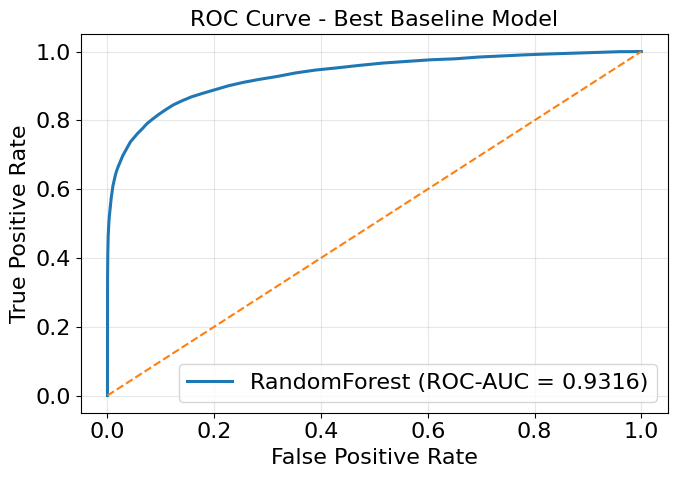

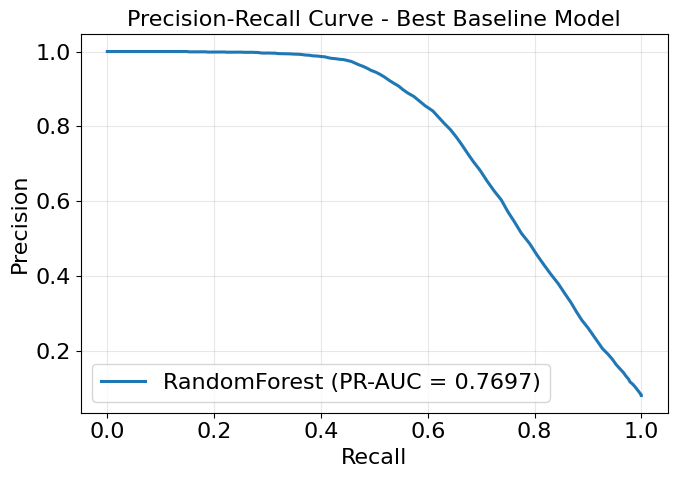

Confusion Matrix of the Best Baseline Model:
[[78938  3561]
 [ 1932  5434]]


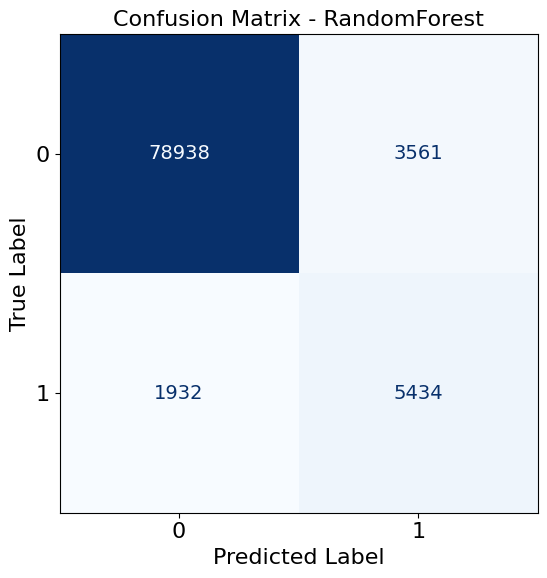

In [70]:
# ============================================================
# CELL 19 — ROC, PR AND CONFUSION MATRIX OF THE BEST BASELINE
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# -----------------------------
# Global font size configuration
# -----------------------------
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "legend.fontsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16
})

best_baseline_name = baseline_results_df.loc[0, "modelo"]
best_baseline_model = trained_baselines[best_baseline_name]

y_val_proba_best = best_baseline_model.predict_proba(X_val_sklearn_imp)[:, 1]

# ============================================================
# ROC CURVE
# ============================================================
fpr, tpr, _ = roc_curve(y_val, y_val_proba_best)
auc_roc_val = roc_auc_score(y_val, y_val_proba_best)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, linewidth=2.2,
         label=f"{best_baseline_name} (ROC-AUC = {auc_roc_val:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Best Baseline Model")
plt.legend(loc="lower right")
plt.grid(False, alpha=0.3)
plt.tight_layout()

plt.savefig(os.path.join(OUTPUT_DIR, "baseline_best_roc_curve.png"),
            dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(OUTPUT_DIR, "baseline_best_roc_curve.pdf"),
            bbox_inches="tight")
plt.show()

# ============================================================
# PRECISION-RECALL CURVE
# ============================================================
precision_curve, recall_curve, _ = precision_recall_curve(y_val, y_val_proba_best)
auc_pr_val = average_precision_score(y_val, y_val_proba_best)

plt.figure(figsize=(7, 5))
plt.plot(recall_curve, precision_curve, linewidth=2.2,
         label=f"{best_baseline_name} (PR-AUC = {auc_pr_val:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Best Baseline Model")
plt.legend(loc="lower left")
plt.grid(False, alpha=0.3)
plt.tight_layout()

plt.savefig(os.path.join(OUTPUT_DIR, "baseline_best_pr_curve.png"),
            dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(OUTPUT_DIR, "baseline_best_pr_curve.pdf"),
            bbox_inches="tight")
plt.show()

# ============================================================
# CONFUSION MATRIX
# ============================================================
best_baseline_threshold = baseline_results_df.loc[0, "threshold"]
y_val_pred_best = (y_val_proba_best >= best_baseline_threshold).astype(int)

cm = confusion_matrix(y_val, y_val_pred_best)
print("Confusion Matrix of the Best Baseline Model:")
print(cm)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", ax=ax, colorbar=False)

ax.set_title(f"Confusion Matrix - {best_baseline_name}")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.tight_layout()

plt.savefig(os.path.join(OUTPUT_DIR, "baseline_best_confusion_matrix.png"),
            dpi=300, bbox_inches="tight")
plt.savefig(os.path.join(OUTPUT_DIR, "baseline_best_confusion_matrix.pdf"),
            bbox_inches="tight")
plt.show()

# ============================================================
# SAVE PREDICTIONS
# ============================================================
np.save(
    os.path.join(OUTPUT_DIR, f"y_val_proba_{best_baseline_name}.npy"),
    y_val_proba_best
)

np.save(
    os.path.join(OUTPUT_DIR, f"y_val_pred_{best_baseline_name}.npy"),
    y_val_pred_best
)

# Confusion Matrix of the Best Baseline Model:
# [[78938  3561]
#  [ 1932  5434]]

In [64]:
print("Conclusão dos baselines:")
print("O RandomForest foi o melhor modelo baseline, com ROC-AUC = 0.9316 e PR-AUC = 0.7697,")
print("além de recall = 0.7377 e precision = 0.6041 na validação.")
print("A LogisticRegression apresentou desempenho insatisfatório, com métricas próximas ao aleatório,")
print("indicando que a relação entre os atributos e o alvo não é adequadamente capturada por uma fronteira linear.")

Conclusão dos baselines:
O RandomForest foi o melhor modelo baseline, com ROC-AUC = 0.9316 e PR-AUC = 0.7697,
além de recall = 0.7377 e precision = 0.6041 na validação.
A LogisticRegression apresentou desempenho insatisfatório, com métricas próximas ao aleatório,
indicando que a relação entre os atributos e o alvo não é adequadamente capturada por uma fronteira linear.


O modelo Random Forest apresentou o melhor desempenho entre os baselines avaliados, alcançando ROC-AUC de 0.9316 e PR-AUC de 0.7697 no conjunto de validação, além de recall de 0.7377 e precision de 0.6041 no threshold ótimo. Em contraste, a Regressão Logística apresentou desempenho insatisfatório, com ROC-AUC de 0.4847 e PR-AUC de 0.0798, sugerindo que a relação entre as variáveis explicativas e a insegurança alimentar não é adequadamente representada por um modelo linear. Esses resultados reforçam a adoção de modelos baseados em árvores e motivam a comparação entre algoritmos de boosting nas etapas seguintes.

## Avaliação dos Modelos Baseline

A Figura 1 apresenta a curva ROC do melhor modelo baseline (Random Forest), evidenciando sua capacidade de discriminação entre as classes. Observa-se que a curva se mantém significativamente acima da linha de referência aleatória, resultando em um valor de ROC-AUC = 0.9316, o que indica excelente separabilidade entre indivíduos com e sem insegurança alimentar. Esse comportamento demonstra que o modelo consegue ordenar corretamente a maioria dos exemplos positivos acima dos negativos ao longo de diferentes limiares de decisão.

A Figura 2 apresenta a curva Precision-Recall (PR), considerada mais informativa em cenários com classes desbalanceadas, como o presente caso (aproximadamente 8% de instâncias positivas). O modelo Random Forest alcançou **PR-AUC = 0.7697**, *valor significativamente superior à prevalência da classe positiva, indicando que o modelo mantém um bom equilíbrio entre precisão e revocação ao longo de diferentes thresholds*. Observa-se que, para níveis moderados de recall, a precisão permanece elevada, o que reforça a capacidade do modelo em identificar corretamente casos de insegurança alimentar sem um aumento excessivo de falsos positivos.

A Figura 3 apresenta a matriz de confusão correspondente ao threshold ótimo identificado (0.13), permitindo uma análise detalhada dos erros do modelo. O Random Forest obteve:

- True Negatives (TN): 78,938
- False Positives (FP): 3,561
- False Negatives (FN): 1,932
- True Positives (TP): 5,434

A partir desses valores, obtêm-se as métricas:

- Recall = 0.7377, indicando que o modelo identifica aproximadamente 73.8% dos casos positivos;
- Precision = 0.6041, sugerindo que cerca de 60.4% das predições positivas são corretas;
- F1-score = 0.6643, refletindo um bom equilíbrio entre precisão e recall.

Esse resultado evidencia que o modelo apresenta uma taxa relativamente baixa de falsos negativos, característica desejável em aplicações relacionadas à detecção de vulnerabilidade social, onde a não identificação de casos reais pode ter impacto significativo.

Em contraste, a Regressão Logística apresentou desempenho substancialmente inferior, com ROC-AUC = 0.4847 e PR-AUC = 0.0798, valores próximos ao comportamento aleatório. Embora tenha atingido recall máximo (1.0), isso ocorreu à custa de uma precisão extremamente baixa (0.0819), indicando que o modelo classificou praticamente todas as instâncias como positivas, tornando-se inadequado para o problema em questão.

De forma geral, os resultados indicam que o problema apresenta relações não lineares e interações complexas entre as variáveis, favorecendo modelos baseados em árvores em detrimento de modelos lineares. O desempenho do Random Forest como baseline estabelece um ponto de referência robusto, servindo como base para a etapa seguinte de comparação entre modelos de boosting (LightGBM e CatBoost), os quais tendem a capturar padrões mais sofisticados nos dados.

In [67]:
# ============================================================
# CÉLULA 20 — SALVAR ARTEFATOS
# ============================================================

joblib.dump(X_train_clipped, os.path.join(OUTPUT_DIR, "X_train_clipped.pkl"))
joblib.dump(X_val_clipped, os.path.join(OUTPUT_DIR, "X_val_clipped.pkl"))
joblib.dump(X_test_clipped, os.path.join(OUTPUT_DIR, "X_test_clipped.pkl"))

joblib.dump(y_train, os.path.join(OUTPUT_DIR, "y_train.pkl"))
joblib.dump(y_val, os.path.join(OUTPUT_DIR, "y_val.pkl"))
joblib.dump(y_test, os.path.join(OUTPUT_DIR, "y_test.pkl"))

joblib.dump(X_trainval_prepared, os.path.join(OUTPUT_DIR, "X_trainval_prepared.pkl"))
joblib.dump(X_test_prepared, os.path.join(OUTPUT_DIR, "X_test_prepared.pkl"))
joblib.dump(y_trainval, os.path.join(OUTPUT_DIR, "y_trainval.pkl"))

joblib.dump(rare_maps, os.path.join(OUTPUT_DIR, "rare_maps.pkl"))
joblib.dump(clip_bounds, os.path.join(OUTPUT_DIR, "clip_bounds.pkl"))
joblib.dump(drop_cols, os.path.join(OUTPUT_DIR, "drop_cols.pkl"))
joblib.dump(scale_pos_weight, os.path.join(OUTPUT_DIR, "scale_pos_weight.pkl"))

baseline_results_df.to_csv(os.path.join(OUTPUT_DIR, "baseline_results_validation.csv"), index=False)

joblib.dump(trained_baselines, os.path.join(OUTPUT_DIR, "trained_baselines.pkl"))


for name, thr_df_model in baseline_threshold_tables.items():
    thr_df_model.to_csv(
        os.path.join(OUTPUT_DIR, f"threshold_table_{name}.csv"),
        index=False
    )

print("Artefatos salvos em:", OUTPUT_DIR)

Artefatos salvos em: outputs/notebook1


In [ ]:
# ============================================================
# CÉLULA 21 — RESUMO FINAL
# ============================================================

print("Resumo do Notebook 1")
print("=" * 60)
print("1. Dados carregados e inspecionados.")
print("2. Alvo limpo e filtrado para valores binários válidos.")
print(f"3. Split temporal realizado: {TRAIN_YEAR} para treino/val e {TEST_YEAR} para teste.")
print("4. Feature engineering aplicado.")
print("5. Leakage e IDs removidos.")
print("6. Tipos ajustados para modelagem.")
print("7. Categorias raras agrupadas.")
print("8. Outliers clipados com base apenas no treino.")
print("9. Baselines treinados e avaliados.")
print("=" * 60)

display(baseline_results_df)

# Resumo do Notebook 1
# ============================================================
# 1. Dados carregados e inspecionados.
# 2. Alvo limpo e filtrado para valores binários válidos.
# 3. Split temporal realizado: 2024 para treino/val e 2025 para teste.
# 4. Feature engineering aplicado.
# 5. Leakage e IDs removidos.
# 6. Tipos ajustados para modelagem.
# 7. Categorias raras agrupadas.
# 8. Outliers clipados com base apenas no treino.
# 9. Baselines treinados e avaliados.
# ============================================================
# ============================================================
# CÉLULA 21 — RESUMO FINAL
# ============================================================

print("Resumo do Notebook 1")
print("=" * 60)
print("1. Dados carregados e inspecionados.")
print("2. Alvo limpo e filtrado para valores binários válidos.")
print(f"3. Split temporal realizado: {TRAIN_YEAR} para treino/val e {TEST_YEAR} para teste.")
print("4. Feature engineering aplicado.")
print("5. Leakage e IDs removidos.")
print("6. Tipos ajustados para modelagem.")
print("7. Categorias raras agrupadas.")
print("8. Outliers clipados com base apenas no treino.")
print("9. Baselines treinados e avaliados.")
print("=" * 60)

display(baseline_results_df)

# Resumo do Notebook 1
# ============================================================
# 1. Dados carregados e inspecionados.
# 2. Alvo limpo e filtrado para valores binários válidos.
# 3. Split temporal realizado: 2024 para treino/val e 2025 para teste.
# 4. Feature engineering aplicado.
# 5. Leakage e IDs removidos.
# 6. Tipos ajustados para modelagem.
# 7. Categorias raras agrupadas.
# 8. Outliers clipados com base apenas no treino.
# 9. Baselines treinados e avaliados.
# ============================================================

# dataset	modelo	threshold	accuracy	precision	recall	f1	auc_roc	auc_pr
# 0	validation	RandomForest	0.13	0.938875	0.604113	0.737714	0.664263	0.931626	0.769669
# 1	validation	LogisticRegression	0.49	0.082157	0.081983	1.000000	0.151542	0.484713	0.079753


Resumo do Notebook 1
1. Dados carregados e inspecionados.
2. Alvo limpo e filtrado para valores binários válidos.
3. Split temporal realizado: 2024 para treino/val e 2025 para teste.
4. Feature engineering aplicado.
5. Leakage e IDs removidos.
6. Tipos ajustados para modelagem.
7. Categorias raras agrupadas.
8. Outliers clipados com base apenas no treino.
9. Baselines treinados e avaliados.


,dataset,modelo,threshold,accuracy,precision,recall,f1,auc_roc,auc_pr
0,validation,RandomForest,0.13,0.938875,0.604113,0.737714,0.664263,0.931626,0.769669
1,validation,LogisticRegression,0.49,0.082157,0.081983,1.000000,0.151542,0.484713,0.079753


## Resultados dos Modelos Baseline

A Tabela X apresenta os resultados dos modelos baseline avaliados no conjunto de validação. Observa-se que o modelo **Random Forest** apresentou desempenho significativamente superior em comparação à **Regressão Logística** em todas as métricas relevantes para o problema.

O Random Forest atingiu **ROC-AUC = 0.9316**, evidenciando excelente capacidade de discriminação entre as classes. Esse comportamento é consistente com a curva ROC apresentada anteriormente, na qual a taxa de verdadeiros positivos cresce rapidamente mesmo para baixos valores de falso positivo, indicando forte separabilidade entre indivíduos com e sem insegurança alimentar.

Em termos de métricas mais adequadas para dados desbalanceados, o modelo alcançou **PR-AUC = 0.7697**, valor substancialmente superior à prevalência da classe positiva (~8%). A curva Precision-Recall associada demonstra que o modelo mantém níveis elevados de precisão para uma ampla faixa de recall, reforçando sua capacidade de identificar corretamente casos positivos sem incorrer em um número excessivo de falsos positivos.

Utilizando o threshold ótimo de **0.13**, determinado por maximização da métrica F2 (com maior peso para recall), o Random Forest obteve:

- **Accuracy = 0.9389**
- **Precision = 0.6041**
- **Recall = 0.7377**
- **F1-score = 0.6643**

Esses resultados indicam um bom equilíbrio entre precisão e revocação, com destaque para o recall relativamente elevado, característica desejável em aplicações relacionadas à detecção de vulnerabilidade social. A matriz de confusão associada evidencia que o modelo consegue recuperar a maioria dos casos positivos, mantendo uma taxa controlada de falsos positivos.

Por outro lado, a Regressão Logística apresentou desempenho insatisfatório, com **ROC-AUC = 0.4847** e **PR-AUC = 0.0798**, valores próximos ao comportamento aleatório. Apesar de alcançar **recall = 1.0**, isso ocorreu à custa de uma **precision extremamente baixa (0.0819)**, indicando que o modelo classificou praticamente todas as instâncias como positivas. Consequentemente, o modelo não é adequado para o problema, pois não consegue discriminar efetivamente entre as classes.

Esses resultados sugerem que o problema em análise envolve **relações não lineares e interações complexas entre as variáveis**, as quais não são adequadamente capturadas por modelos lineares. Em contraste, modelos baseados em árvores, como o Random Forest, demonstram maior capacidade de modelar tais relações.

Dessa forma, o Random Forest é adotado como **baseline de referência**, e seus resultados estabelecem um ponto comparativo robusto para a etapa seguinte do estudo, que envolve a avaliação de modelos mais avançados baseados em boosting, como **LightGBM** e **CatBoost**, os quais tendem a apresentar desempenho superior em cenários com alta complexidade estrutural dos dados.

## 2) Resultados 

### 2.1 Estrutura e preparação dos dados

| Etapa | Resultado |
|---|---:|
| Base original lida | 6.038.705 linhas |
| Colunas originais | 171 |
| Registros com alvo válido | 880.359 |
| Proporção positiva global | 8,2773% |
| Treino/validação (2024) | 449.323 linhas |
| Teste temporal (2025) | 431.036 linhas |
| Colunas após feature engineering | 337 |
| Colunas após remoção de leakage/ID | 334 |
| Colunas removidas por missing >=95% | 74 |
| Colunas finais para modelagem | 261 |
| Categóricas finais | 214 |
| Numéricas finais | 47 |
| Treino final | 359.458 linhas |
| Validação final | 89.865 linhas |
| Teste final | 431.036 linhas |

### 2.2 Distribuição do alvo

| Recorte | Classe 0 | Classe 1 | Proporção classe 1 |
|---|---:|---:|---:|
| Base válida total | 807.489 | 72.870 | 0.082773 |
| 2024 | 412.492 | 36.831 | 0.081970 |
| 2025 | 394.997 | 36.039 | 0.083610 |

### 2.3 Baselines na validação

| dataset | modelo | threshold | accuracy | precision | recall | f1 | auc_roc | auc_pr |
|---|---|---:|---:|---:|---:|---:|---:|---:|
| validation | RandomForest | 0.13 | 0.938875 | 0.604113 | 0.737714 | 0.664263 | 0.931626 | 0.769669 |
| validation | LogisticRegression | 0.49 | 0.082157 | 0.081983 | 1.000000 | 0.151542 | 0.484713 | 0.079753 |

---

## 3) Resultado final do arquivo 1

| Critério | Melhor resultado |
|---|---|
| Melhor baseline | RandomForest |
| Threshold ótimo | 0.13 |
| ROC-AUC | 0.931626 |
| PR-AUC | 0.769669 |
| Precision | 0.604113 |
| Recall | 0.737714 |
| F1 | 0.664263 |

### Leitura final
- Este notebook deixa a base metodologicamente pronta.
- O pipeline de limpeza e split temporal está coerente.
- O **RandomForest** foi claramente o melhor baseline.
- A **LogisticRegression** ficou praticamente inadequada para o problema, com desempenho próximo do aleatório em termos discriminativos.